# Question 4 — Deep Q-Network (DQN) for Connect-4

**M1 (DQN backbone)** is loaded from `mihir_cnn_connect4.h5` (Mihir CNN from Project 1). The final classification layer is replaced with `Dense(7, tanh)` for Q-values (**4c**).

**Opponent pool (M2):** classmates' CNNs where available, a copy of the original Mihir CNN as a frozen opponent, your policy-gradient agent from **`mihir_pg_trained.keras`** (**4d**), and optionally snapshots of the DQN itself during training.

This notebook implements Project 3 Part 4:
- **4c** — DQN built from the same architecture as your PG/CNN stack, softmax → tanh on the last layer
- **4a** — State from the DQN perspective; next state after the opponent moves
- **4b** — Random rollouts to non-empty starts (not stored in replay)
- **4** — ε-greedy, replay buffer, target network, ε decay
- **4d** — Train including the PG agent in the pool; final comparison highlights **DQN vs `mihir_pg_trained.keras`**


In [2]:
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import zipfile
import os
import matplotlib.pyplot as plt
from collections import deque

print("TensorFlow:", tf.__version__)
print("PyTorch:   ", torch.__version__)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# NOTE: Run with Python 3.11 (or 3.12). Kernel -> Change Kernel -> Python 3.11
ROWS, COLS = 6, 7

TensorFlow: 2.20.0
PyTorch:    2.9.1+cpu


## 4c — DQN Architecture

We load **M1** from `mihir_cnn_connect4.h5`, strip the final softmax layer,
and attach a new `Dense(7, activation='tanh')` output.  
Tanh outputs values in `(-1, 1)`, which naturally represents Q-values where
`+1 ≈ certain win` and `-1 ≈ certain loss`.

In [3]:
import json
import tempfile
import os

from tensorflow.keras.models import model_from_json


def load_keras_without_quant_config(path):
    '''Load a .keras zip where layer configs contain quantization_config (some Keras 3 builds reject it).'''
    with zipfile.ZipFile(path, "r") as z:
        config = json.loads(z.read("config.json"))

        def clean(obj):
            if isinstance(obj, dict):
                obj.pop("quantization_config", None)
                for v in obj.values():
                    clean(v)
            elif isinstance(obj, list):
                for v in obj:
                    clean(v)

        clean(config)
        model = model_from_json(json.dumps(config))

        names = z.namelist()
        weight_member = next(
            (n for n in names if n.endswith("model.weights.h5") or n.endswith(".weights.h5")),
            None,
        )
        if weight_member is None:
            raise FileNotFoundError(f"No weights file in {path}. Zip entries: {names}")

        with tempfile.TemporaryDirectory() as tmp:
            z.extract(weight_member, tmp)
            wpath = os.path.join(tmp, weight_member)
            model.load_weights(wpath)

    return model


# ── 4c: DQN from M1 = mihir_cnn_connect4.h5 (softmax → tanh) ─────────────────

M1_PATH = "mihir_cnn_connect4.h5"
m1_base = tf.keras.models.load_model(M1_PATH, compile=False)
print("M1 base CNN loaded —", M1_PATH, "— input:", m1_base.input_shape, "output:", m1_base.output_shape)

x = m1_base.layers[-2].output
q_out = tf.keras.layers.Dense(7, activation="tanh", name="q_values")(x)
dqn_model = tf.keras.Model(inputs=m1_base.input, outputs=q_out)

target_model = tf.keras.models.clone_model(dqn_model)
target_model.set_weights(dqn_model.get_weights())
initial_dqn_weights = dqn_model.get_weights()  # snapshot for clean restarts

print("DQN built — tanh Q-head:", dqn_model.output_shape)
print("Target network — initialised from DQN")

# ── M2 opponents ─────────────────────────────────────────────────────────────

m2_sophia = tf.keras.models.load_model("Sophia_CNN.keras", compile=False)
print("\nSophia CNN inputs:", [i.name for i in m2_sophia.inputs])

m2_paolo = tf.keras.models.load_model("paolo_cnn.keras", compile=False)
print("Paolo CNN input:", m2_paolo.input_shape)

m2_mihir_orig = tf.keras.models.load_model(M1_PATH, compile=False)
print("Mihir original CNN (frozen clone of M1) input:", m2_mihir_orig.input_shape)

m2_cass = tf.keras.models.load_model("cass_cnn_connect4.keras", compile=False)
print("Cass CNN input:", m2_cass.input_shape)

# 4d: your PG-trained agent — needs config strip (see loader above)
PG_PATH = "mihir_pg_trained.keras"
m2_mihir_pg = load_keras_without_quant_config(PG_PATH)
print("Mihir PG agent —", PG_PATH, "— input:", m2_mihir_pg.input_shape)

opponent_pool = [
    (m2_sophia, "sophia"),
    (m2_paolo, "tf"),
    (m2_cass, "tf"),
    (m2_mihir_orig, "tf"),
    (m2_mihir_pg, "tf"),
]

print(f"\nOpponent pool: {len(opponent_pool)} (includes PG for 4d)")


M1 base CNN loaded — mihir_cnn_connect4.h5 — input: (None, 6, 7, 2) output: (None, 7)
DQN built — tanh Q-head: (None, 7)
Target network — initialised from DQN

Sophia CNN inputs: ['board', 'mask']
Paolo CNN input: (None, 6, 7, 2)
Mihir original CNN (frozen clone of M1) input: (None, 6, 7, 2)
Cass CNN input: (None, 6, 7, 2)
Mihir PG agent — mihir_pg_trained.keras — input: (None, 6, 7, 2)

Opponent pool: 5 (includes PG for 4d)


## Connect-4 Game Logic

In [4]:
def create_board():
    return np.zeros((ROWS, COLS), dtype=int)

def drop_piece(board, col, player):
    board = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if board[row][col] == 0:
            board[row][col] = player
            return board
    return board

def get_legal_moves(board):
    return [c for c in range(COLS) if board[0][c] == 0]

def get_mask(board):
    return np.array([1.0 if board[0][c] == 0 else 0.0 for c in range(COLS)], dtype=np.float32)

def check_win(board, player):
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r][c+i] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS):
            if all(board[r+i][c] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r+i][c+i] == player for i in range(4)): return True
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if all(board[r-i][c+i] == player for i in range(4)): return True
    return False

def encode_board(board, player):
    """Encode board from the given player's perspective: (6, 7, 2) float32.
    Channel 0 = player's pieces, channel 1 = opponent's pieces."""
    opp = 3 - player
    enc = np.zeros((ROWS, COLS, 2), dtype=np.float32)
    enc[:, :, 0] = (board == player).astype(np.float32)
    enc[:, :, 1] = (board == opp).astype(np.float32)
    return enc

# Opponent move helpers
def get_winning_move(board, player):
    for col in get_legal_moves(board):
        if check_win(drop_piece(board, col, player), player):
            return col
    return None

def get_non_losing_moves(board, player):
    opp = 3 - player
    legal = get_legal_moves(board)
    safe = [c for c in legal if not any(
        check_win(drop_piece(drop_piece(board, c, player), oc, opp), opp)
        for oc in get_legal_moves(drop_piece(board, c, player))
    )]
    return safe if safe else legal

def get_opponent_move(board, m2_player, m2_model, m2_type, use_tactics=True, temperature=1.0):
    """Opponent move policy.
    - use_tactics=True: win > block > sample from non-losing (strong)
    - use_tactics=False: pure policy sampling over legal moves (softer)
    """
    legal = get_legal_moves(board)
    if not legal:
        return None

    probs = get_probs(m2_model, m2_type, board, m2_player)

    if not use_tactics:
        return sample_move(probs, legal, temperature=temperature)

    m1_player = 3 - m2_player
    col = get_winning_move(board, m2_player)
    if col is None:
        col = get_winning_move(board, m1_player)
    if col is None:
        safe = get_non_losing_moves(board, m2_player)
        col = sample_move(probs, safe, temperature=temperature)
    return col

# Move selection helpers
def get_probs(model, model_type, board, player):
    if model_type == "sophia":
        enc  = encode_board(board, player)[np.newaxis]
        mask = get_mask(board)[np.newaxis]
        logits = model([enc, mask], training=False).numpy()[0]
        logits -= logits.max()
        e = np.exp(logits); return e / e.sum()
    elif model_type == "pytorch":
        enc = encode_board(board, player)[np.newaxis]
        with torch.no_grad():
            probs = model(torch.tensor(enc)).numpy()[0]
        mask = get_mask(board)
        probs *= mask
        s = probs.sum()
        return probs / s if s > 1e-8 else mask / mask.sum()
    elif model_type == "dqn":
        # DQN outputs tanh Q-values in (-1, 1) — convert to probs via softmax
        enc = encode_board(board, player)[np.newaxis]
        q_vals = model(enc, training=False).numpy()[0]
        mask = get_mask(board)
        q_vals[mask == 0] = -1e9   # mask illegal moves before softmax
        q_vals -= q_vals.max()     # numerical stability
        e = np.exp(q_vals) * mask
        return e / e.sum()
    else:  # "tf" — softmax CNN models (Paolo, Mihir, PG)
        enc   = encode_board(board, player)[np.newaxis]
        probs = model(enc, training=False).numpy()[0]
        mask = get_mask(board)
        probs *= mask
        s = probs.sum()
        return probs / s if s > 1e-8 else mask / mask.sum()

def sample_move(probs, legal_moves, temperature=1.0):
    lp = np.array([probs[c] for c in legal_moves], dtype=np.float64)
    if temperature != 1.0:
        lp = lp ** (1.0 / temperature)
    s = lp.sum()
    lp = lp / s if s > 1e-8 else np.ones(len(legal_moves)) / len(legal_moves)
    return int(np.random.choice(legal_moves, p=lp))

print("Game logic functions defined.")

Game logic functions defined.


## 4a — State Representation

The **state** fed to the DQN is the board encoded from the DQN's own perspective
(`encode_board(board, dqn_player)`), with channel 0 = DQN pieces and channel 1 = opponent pieces.

The **next state** is the board *after the opponent has responded* — i.e., the board
the DQN will see on its *next turn*. This is the coin-game convention from class:
the DQN's action leads to an immediate reward, then the opponent moves,
and the resulting board is the next state.

## 4b — Random Board Initialization

Starting every game from an empty board makes early training very hard — the DQN always loses and never sees a winning position. Instead, we play `N_RANDOM_INIT_MIN`–`N_RANDOM_INIT_MAX` moves completely at random before the strategic phase begins.

**Important:** we do **not** store these random moves in the replay buffer.
The DQN only learns from the strategic decisions it makes after the random initialization.

In [5]:
def random_init_board(n_moves=4):
    """Play n_moves completely random moves to get a non-empty starting board.
    Returns (board, current_player) — the player whose turn it is next.
    Resets if the random moves accidentally end the game."""
    board = create_board()
    current = 1
    for _ in range(n_moves):
        legal = get_legal_moves(board)
        if not legal:
            return create_board(), 1  # board full — reset
        col = random.choice(legal)
        board = drop_piece(board, col, current)
        if check_win(board, current) or not get_legal_moves(board):
            return create_board(), 1  # random init ended game — reset
        current = 3 - current
    return board, current

print("random_init_board() defined.")

random_init_board() defined.


## 4 — Training Setup

The DQN uses four standard techniques:
- **Memory replay buffer** — stores `(state, action, reward, next_state, done)` tuples; training samples a random mini-batch each step to break temporal correlations
- **Epsilon-greedy policy** — with probability `ε` choose a random legal move (explore); otherwise choose `argmax Q(s,a)` (exploit)
- **Epsilon annealing** — `ε` decays from 1.0 → 0.1 over training so the agent gradually shifts from exploration to exploitation
- **Target network** — a frozen copy of the DQN used to compute TD targets; synced every `TARGET_UPDATE_EVERY` episodes to stabilise training

In [10]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
N_EPISODES          = 8000    # increased from 1500 — DQN needs more experience
N_RANDOM_INIT_MIN   = 2       # random init moves: sample uniformly in [MIN, MAX]
N_RANDOM_INIT_MAX   = 8       # wider range → more diverse starting boards
BATCH_SIZE          = 64      # replay mini-batch size (MUST stay constant — TF graph)
MEMORY_SIZE         = 50_000  # increased from 10_000 — retains more diverse experience
GAMMA               = 0.99    # 0.95→0.99: Connect-4 can last 42 moves; 0.95^20≈0.36 (bad credit for early moves)
EPSILON_START       = 1.0     # starting exploration rate
EPSILON_MIN         = 0.10    # minimum exploration rate
EPSILON_DECAY       = 0.9993  # slower decay — reaches 0.1 around episode 3500
TARGET_UPDATE_EVERY = 50      # sync target network every N episodes
ADD_DQN_EVERY       = 150     # add a DQN snapshot to opponent pool every N episodes
MAX_DQN_COPIES      = 2       # fewer self-play copies keeps pool quality high
WIN_RATE_THRESHOLD  = 0.70    # minimum win rate required before adding a DQN copy
LOG_EVERY           = 50      # print progress every N episodes
EVAL_GAMES          = 30      # games used for evaluation during training
N_GRADIENT_STEPS    = 4       # gradient updates per game step — 4x more learning per episode
N_STEP              = 1       # rollback to 1-step TD targets for stability
EARLY_STOP_PATIENCE = 5       # stop if win rate declines this many evals in a row
# ──────────────────────────────────────────────────────────────────────────────

memory  = deque(maxlen=MEMORY_SIZE)
epsilon = EPSILON_START

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def train_step(states, actions, targets):
    """One gradient descent step on a mini-batch of (state, action, target_Q) triples.
    Uses MSE loss between predicted Q(s,a) and the Bellman target.
    Batch size must remain constant to avoid TF graph recompilation."""
    with tf.GradientTape() as tape:
        q_all    = dqn_model(states, training=True)           # (B, 7) Q-values
        one_hot  = tf.one_hot(actions, COLS)                  # (B, 7)
        q_chosen = tf.reduce_sum(q_all * one_hot, axis=1)    # (B,) predicted Q for taken action
        loss     = tf.keras.losses.MSE(targets, q_chosen)
    grads = tape.gradient(loss, dqn_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, dqn_model.trainable_variables))
    return loss

def select_action_epsilon_greedy(board, dqn_player, eps):
    """Epsilon-greedy action selection from DQN's perspective.
    Illegal columns are masked out before taking the argmax."""
    legal = get_legal_moves(board)
    if np.random.rand() < eps:
        return random.choice(legal)
    enc    = encode_board(board, dqn_player)[np.newaxis]
    q_vals = dqn_model(enc, training=False).numpy()[0]  # (7,)
    # Mask illegal moves with a large negative value
    mask   = get_mask(board)
    q_vals = q_vals * mask + (mask - 1) * 1e9           # illegal → -1e9
    return int(np.argmax(q_vals))

print(f"Training setup complete.")
print(f"  Episodes: {N_EPISODES}, Batch size: {BATCH_SIZE}, Memory: {MEMORY_SIZE}")
print(f"  Epsilon: {EPSILON_START} → {EPSILON_MIN} (decay {EPSILON_DECAY})")
print(f"  Gamma: {GAMMA}, Target update every: {TARGET_UPDATE_EVERY} episodes")
print(f"  Random init range: {N_RANDOM_INIT_MIN}–{N_RANDOM_INIT_MAX} moves")
print(f"  Gamma: {GAMMA}, gradient steps per move: {N_GRADIENT_STEPS}")
print(f"  Early-stop patience: {EARLY_STOP_PATIENCE} consecutive declines")

Training setup complete.
  Episodes: 8000, Batch size: 64, Memory: 50000
  Epsilon: 1.0 → 0.1 (decay 0.9993)
  Gamma: 0.99, Target update every: 50 episodes
  Random init range: 2–8 moves
  Gamma: 0.99, gradient steps per move: 4
  Early-stop patience: 5 consecutive declines


## 4 — Training Loop

Each episode:
1. Randomly initialise the board with a few moves (**4b**)
2. Randomly assign whether the DQN plays as player 1 or player 2
3. Randomly choose an opponent from the pool (**4**)
4. Strategic phase: DQN uses epsilon-greedy; opponent uses smart strategy (**4a**)
5. Store `(state, action, reward, next_state, done)` in the replay buffer
6. Sample a random mini-batch and take one gradient step
7. Periodically sync the target network and add DQN snapshots to the pool

In [6]:
import time

win_rate_log  = []
loss_log      = []
eps_log       = []
n_dqn_copies        = 0
best_win_rate        = 0.0   # peak win rate seen — used for model checkpointing
consecutive_declines = 0     # consecutive eval windows where win rate went down

# Fix 2: scaled rewards keep Bellman targets in the active (-0.95, 0.95) range of tanh,
# avoiding gradient saturation at the flat ends of the activation function.
R_WIN  =  0.5    # was +1.0
R_LOSS = -0.5    # was -1.0
R_DRAW =  0.025  # was +0.05

# Hard reset training state so repeated notebook runs are comparable.
# (Prevents stale epsilon/replay/weights from previous partial runs.)
if 'initial_dqn_weights' in globals():
    dqn_model.set_weights(initial_dqn_weights)
target_model.set_weights(dqn_model.get_weights())
memory = deque(maxlen=MEMORY_SIZE)
epsilon = EPSILON_START

print(f"Starting DQN training... (epsilon reset to {epsilon:.3f}, memory cleared)")
last_log_print_time = time.perf_counter()  # wall time between Ep ... lines

for episode in range(N_EPISODES):
    t_ep_start = time.perf_counter()

    # ── 4b: Random board initialisation ──────────────────────────────────────
    board, current_player = random_init_board(random.randint(N_RANDOM_INIT_MIN, N_RANDOM_INIT_MAX))

    # Randomly assign which player the DQN controls this episode
    dqn_player = random.choice([1, 2])
    opp_player = 3 - dqn_player

    # Randomly choose an opponent from the pool
    m2_model, m2_type = random.choice(opponent_pool)

    # Rollback: keep opponents tactical throughout (matches your better baseline behavior).
    opp_use_tactics = True
    opp_temp = 1.0

    # If it's the opponent's turn first (after random init), let them move once
    if current_player == opp_player:
        legal = get_legal_moves(board)
        if legal:
            col = get_opponent_move(
                board, opp_player, m2_model, m2_type,
                use_tactics=opp_use_tactics, temperature=opp_temp
            )
            board = drop_piece(board, col, opp_player)
            if check_win(board, opp_player) or not get_legal_moves(board):
                continue
        current_player = dqn_player

    done = False
    ep_loss = []
    nstep_buffer = deque()  # stores recent 1-step transitions for n-step return construction

    # ── 4a: Strategic phase — DQN turn by turn ───────────────────────────────
    while not done:
        legal = get_legal_moves(board)
        if not legal:
            break

        state  = encode_board(board, dqn_player)
        action = select_action_epsilon_greedy(board, dqn_player, epsilon)
        board_after_dqn = drop_piece(board, action, dqn_player)

        if check_win(board_after_dqn, dqn_player):
            reward     = R_WIN
            next_state = encode_board(board_after_dqn, dqn_player)
            done       = True

        elif not get_legal_moves(board_after_dqn):
            reward     = R_DRAW
            next_state = encode_board(board_after_dqn, dqn_player)
            done       = True

        else:
            opp_col         = get_opponent_move(
                board_after_dqn, opp_player, m2_model, m2_type,
                use_tactics=opp_use_tactics, temperature=opp_temp
            )
            board_after_opp = drop_piece(board_after_dqn, opp_col, opp_player)

            if check_win(board_after_opp, opp_player):
                reward = R_LOSS
                done   = True
            elif not get_legal_moves(board_after_opp):
                reward = R_DRAW
                done   = True
            else:
                reward = 0.0

            next_state = encode_board(board_after_opp, dqn_player)
            board      = board_after_opp

        # Store 1-step transition temporarily, then emit n-step transitions to replay.
        nstep_buffer.append((state, action, reward, next_state, float(done)))

        if len(nstep_buffer) >= N_STEP:
            n_return = 0.0
            for i in range(N_STEP):
                n_return += (GAMMA ** i) * nstep_buffer[i][2]
            s0, a0 = nstep_buffer[0][0], nstep_buffer[0][1]
            ns_n   = nstep_buffer[N_STEP - 1][3]
            d_n    = nstep_buffer[N_STEP - 1][4]
            memory.append((s0, a0, n_return, ns_n, d_n, N_STEP))
            nstep_buffer.popleft()

        # Flush tail transitions at episode end so no experience is discarded.
        if done:
            while nstep_buffer:
                k = len(nstep_buffer)
                n_return = 0.0
                for i in range(k):
                    n_return += (GAMMA ** i) * nstep_buffer[i][2]
                s0, a0 = nstep_buffer[0][0], nstep_buffer[0][1]
                ns_k   = nstep_buffer[-1][3]
                d_k    = nstep_buffer[-1][4]
                memory.append((s0, a0, n_return, ns_k, d_k, k))
                nstep_buffer.popleft()

        if len(memory) >= BATCH_SIZE:
            for _grad_step in range(N_GRADIENT_STEPS):
                batch      = random.sample(memory, BATCH_SIZE)
                s_batch    = np.array([t[0] for t in batch], dtype=np.float32)
                a_batch    = np.array([t[1] for t in batch], dtype=np.int32)
                r_batch    = np.array([t[2] for t in batch], dtype=np.float32)
                ns_batch   = np.array([t[3] for t in batch], dtype=np.float32)
                done_batch = np.array([t[4] for t in batch], dtype=np.float32)
                n_batch    = np.array([t[5] for t in batch], dtype=np.float32)

                # Build legal-move mask from encoded next states.
                # In encode_board(...), occupied top cells have channel0+channel1 > 0.
                legal_mask = (np.sum(ns_batch[:, 0, :, :], axis=-1) == 0).astype(np.float32)  # (B, 7)

                # Double DQN target with illegal-action masking:
                # online net selects best legal action, target net evaluates it.
                online_q        = dqn_model(ns_batch, training=False).numpy()    # (B, 7)
                online_q_masked = np.where(legal_mask > 0.0, online_q, -1e9)
                best_acts       = np.argmax(online_q_masked, axis=1)

                target_q        = target_model(ns_batch, training=False).numpy()  # (B, 7)
                target_q_masked = np.where(legal_mask > 0.0, target_q, -1e9)
                best_q          = target_q_masked[np.arange(BATCH_SIZE), best_acts]

                discounts = np.power(GAMMA, n_batch)
                y_batch   = r_batch + (1 - done_batch) * discounts * best_q
                y_batch   = y_batch.astype(np.float32)

                loss_val = train_step(
                    tf.constant(s_batch), tf.constant(a_batch), tf.constant(y_batch)
                )
                ep_loss.append(float(loss_val))

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    eps_log.append(epsilon)
    if ep_loss:
        loss_log.append(float(np.mean(ep_loss)))

    if (episode + 1) % TARGET_UPDATE_EVERY == 0:
        target_model.set_weights(dqn_model.get_weights())

    ep_sec = time.perf_counter() - t_ep_start  # this episode only (excludes periodic eval)

    if (episode + 1) % LOG_EVERY == 0:
        # Evaluate vs Mihir original CNN (alternating P1/P2) — measures real strategic progress
        wins = 0
        for k in range(EVAL_GAMES):
            eval_dqn_p = (k % 2) + 1   # alternate: half games as P1, half as P2
            eval_opp_p = 3 - eval_dqn_p
            b_eval = create_board()
            p_eval = 1
            for _ in range(42):
                leg = get_legal_moves(b_eval)
                if not leg: break
                if p_eval == eval_dqn_p:
                    mv = select_action_epsilon_greedy(b_eval, eval_dqn_p, eps=0.0)
                else:
                    mv = get_opponent_move(b_eval, eval_opp_p, m2_mihir_orig, "tf")
                b_eval = drop_piece(b_eval, mv, p_eval)
                if check_win(b_eval, p_eval):
                    if p_eval == eval_dqn_p: wins += 1
                    break
                p_eval = 3 - p_eval

        wr       = wins / EVAL_GAMES
        avg_loss = float(np.mean(loss_log[-LOG_EVERY:])) if loss_log else float("nan")

        # ── Best-model checkpoint ─────────────────────────────────────────────
        ckpt_note = ""
        if wr > best_win_rate:
            best_win_rate = wr
            dqn_model.save("mihir_dqn_best.keras")
            ckpt_note = " ★ best saved"

        # ── Early-stopping: count consecutive win-rate declines ───────────────
        if win_rate_log and wr < win_rate_log[-1]:
            consecutive_declines += 1
        else:
            consecutive_declines = 0   # reset on flat or improvement

        win_rate_log.append(wr)
        now = time.perf_counter()
        sec_since_last_log = now - last_log_print_time
        last_log_print_time = now
        print(f"Ep {episode+1:5d} | ε={epsilon:.3f} | win vs Mihir CNN={wr:.2f} "
              f"| avg loss={avg_loss:.4f} | pool={len(opponent_pool)}"
              f" | declines={consecutive_declines} | ep={ep_sec:.1f}s | "
              f"since_last={sec_since_last_log:.0f}s{ckpt_note}")

        # ── Trigger early stop if win rate declined EARLY_STOP_PATIENCE times ─
        if consecutive_declines >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping: win rate declined for {EARLY_STOP_PATIENCE} "
                  f"consecutive evaluations.")
            print(f"  Peak win rate was {best_win_rate:.2f}. Restoring best weights...")
            dqn_model.load_weights("mihir_dqn_best.keras")
            break

    if ((episode + 1) % ADD_DQN_EVERY == 0
            and n_dqn_copies < MAX_DQN_COPIES):
        w_tmp = 0
        for _ in range(30):
            bt = create_board(); pt = 1
            for __ in range(42):
                lg = get_legal_moves(bt)
                if not lg: break
                mv = select_action_epsilon_greedy(bt, 1, 0.0) if pt==1 else random.choice(lg)
                bt = drop_piece(bt, mv, pt)
                if check_win(bt, pt):
                    if pt == 1: w_tmp += 1
                    break
                pt = 3 - pt
        if w_tmp / 30 >= WIN_RATE_THRESHOLD:
            snap = tf.keras.models.clone_model(dqn_model)
            snap.set_weights(dqn_model.get_weights())
            opponent_pool.append((snap, "dqn"))
            n_dqn_copies += 1
            print(f"  → DQN snapshot added to pool (total: {len(opponent_pool)})")

print("\nTraining complete!")

Starting DQN training... (epsilon reset to 1.000, memory cleared)
Ep    50 | ε=0.966 | win vs Mihir CNN=0.00 | avg loss=0.1089 | pool=5 | declines=0 | ep=1.3s | since_last=53s
Ep   100 | ε=0.933 | win vs Mihir CNN=0.00 | avg loss=0.0588 | pool=5 | declines=0 | ep=1.1s | since_last=141s
Ep   150 | ε=0.902 | win vs Mihir CNN=0.03 | avg loss=0.0395 | pool=5 | declines=0 | ep=0.5s | since_last=129s ★ best saved
  → DQN snapshot added to pool (total: 6)
Ep   200 | ε=0.872 | win vs Mihir CNN=0.17 | avg loss=0.0325 | pool=6 | declines=0 | ep=4.2s | since_last=169s ★ best saved
Ep   250 | ε=0.842 | win vs Mihir CNN=0.07 | avg loss=0.0229 | pool=6 | declines=1 | ep=1.4s | since_last=174s
Ep   300 | ε=0.815 | win vs Mihir CNN=0.43 | avg loss=0.0183 | pool=6 | declines=0 | ep=4.7s | since_last=157s ★ best saved
  → DQN snapshot added to pool (total: 7)
Ep   350 | ε=0.788 | win vs Mihir CNN=0.43 | avg loss=0.0139 | pool=7 | declines=0 | ep=4.0s | since_last=191s
Ep   400 | ε=0.762 | win vs Mihir C

*After training completes, run the **4d** evaluation cell, then the results plots.*


## 4d — DQN vs policy-gradient agent (`mihir_pg_trained.keras`)

The assignment asks you to have the DQN play against the PG agent you trained in steps 1–3. That agent is **`mihir_pg_trained.keras`**; it is in the training opponent pool and is evaluated **last** below so the bar chart ends with the PG comparison.


In [6]:
dqn_model = tf.keras.models.load_model("mihir_dqn_best.keras", compile=False)
print("dqn model:", dqn_model.input_shape)

dqn model: (None, 6, 7, 2)


In [11]:
# ── 4d: Head-to-head — trained DQN vs each opponent ─────────────────────────

def play_head_to_head(model_a, type_a, model_b, type_b, n_games=100, temp=0.3):
    '''Alternating first player. For DQN, greedy (eps=0) masked argmax.'''
    w, l, d = 0, 0, 0
    for i in range(n_games):
        player_a = (i % 2) + 1
        player_b = 3 - player_a
        board = create_board()
        current = 1
        while True:
            legal = get_legal_moves(board)
            if not legal:
                d += 1
                break
            if current == player_a:
                if type_a == "dqn":
                    col = select_action_epsilon_greedy(board, player_a, eps=0.0)
                else:
                    col = sample_move(get_probs(model_a, type_a, board, player_a), legal, temp)
            else:
                if type_b == "dqn":
                    col = select_action_epsilon_greedy(board, player_b, eps=0.0)
                else:
                    col = sample_move(get_probs(model_b, type_b, board, player_b), legal, temp)
            board = drop_piece(board, col, current)
            if check_win(board, current):
                if current == player_a:
                    w += 1
                else:
                    l += 1
                break
            current = 3 - current
    return w, l, d


N_EVAL = 100
print(f"DQN vs each opponent ({N_EVAL} games each; DQN greedy, CNNs sampled temp=0.3):\n")

# PG agent last for the Part 4d comparison chart
eval_opponents = [
    ("vs Original Mihir CNN", m2_mihir_orig, "tf"),
    ("vs Sophia CNN", m2_sophia, "sophia"),
    ("vs Paolo CNN", m2_paolo, "tf"),
    ("vs Cass CNN", m2_cass, "tf"),
    ("vs Mihir PG (mihir_pg_trained.keras)", m2_mihir_pg, "tf"),
]

eval_results = {}
for label, opp_model, opp_type in eval_opponents:
    w, l, d = play_head_to_head(dqn_model, "dqn", opp_model, opp_type, N_EVAL)
    eval_results[label] = (w, l, d)
    print(f"{label}:")
    print(f"  W={w:3d} ({w/N_EVAL:.0%})  L={l:3d} ({l/N_EVAL:.0%})  D={d:3d} ({d/N_EVAL:.0%})")
    print()


DQN vs each opponent (100 games each; DQN greedy, CNNs sampled temp=0.3):

vs Original Mihir CNN:
  W= 40 (40%)  L= 60 (60%)  D=  0 (0%)

vs Sophia CNN:
  W= 31 (31%)  L= 66 (66%)  D=  3 (3%)

vs Paolo CNN:
  W= 53 (53%)  L= 38 (38%)  D=  9 (9%)

vs Cass CNN:
  W= 46 (46%)  L= 54 (54%)  D=  0 (0%)

vs Mihir PG (mihir_pg_trained.keras):
  W= 75 (75%)  L= 21 (21%)  D=  4 (4%)



## Results and evaluation

Training curves: win rate vs a random player (diagnostic), ε decay, and loss. The bar chart summarizes win / draw / loss rates against each opponent; the **rightmost bar** is **vs `mihir_pg_trained.keras`** (PG), as required for the Part **4d** comparison.


NameError: name 'win_rate_log' is not defined

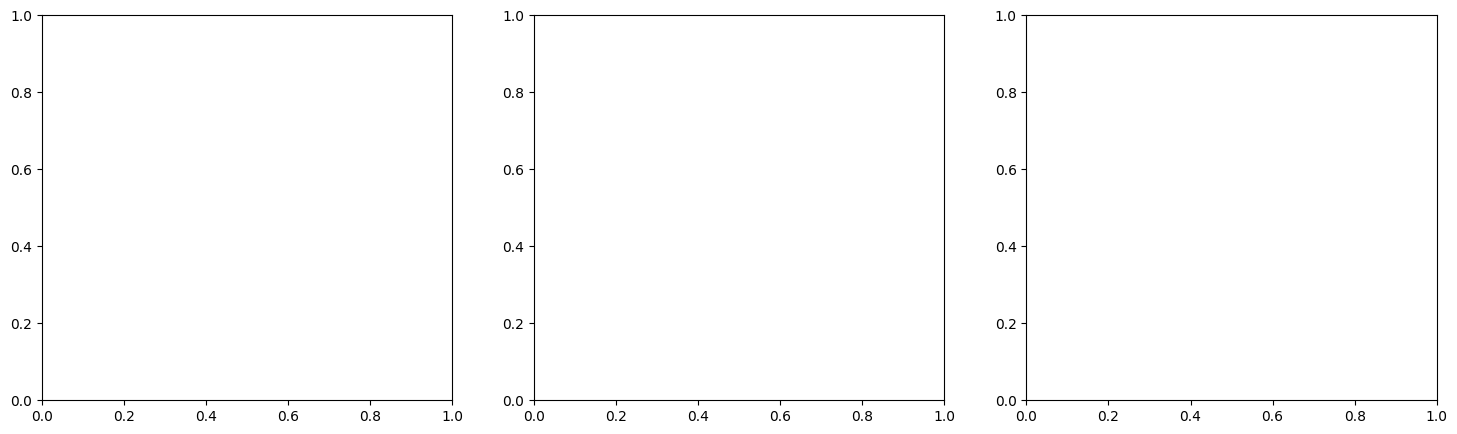

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Win rate vs random opponent over training ─────────────────────────
ax = axes[0]
x_eval = [(i + 1) * LOG_EVERY for i in range(len(win_rate_log))]
ax.plot(x_eval, win_rate_log, color="steelblue", linewidth=1.5, marker="o",
        markersize=3, label="Win rate vs random")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(WIN_RATE_THRESHOLD, color="green", linestyle="--", linewidth=0.8,
           label=f"Snapshot threshold ({WIN_RATE_THRESHOLD:.0%})")
ax.set_xlabel("Episode"); ax.set_ylabel("Win Rate")
ax.set_title("DQN Win Rate vs Random Opponent")
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 2: Epsilon decay ─────────────────────────────────────────────────────
ax = axes[1]
ax.plot(eps_log, color="darkorange", linewidth=1.2)
ax.set_xlabel("Episode"); ax.set_ylabel("Epsilon")
ax.set_title("Epsilon Annealing (Exploration → Exploitation)")
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

# ── Plot 3: Final evaluation bar chart ───────────────────────────────────────
ax = axes[2]
labels    = [k.replace("vs ", "") for k in eval_results]
win_vals  = [v[0] / N_EVAL for v in eval_results.values()]
draw_vals = [v[2] / N_EVAL for v in eval_results.values()]
loss_vals = [v[1] / N_EVAL for v in eval_results.values()]
x = np.arange(len(labels)); w_bar = 0.25

ax.bar(x - w_bar, win_vals,  w_bar, label="Win",  color="steelblue")
ax.bar(x,         draw_vals, w_bar, label="Draw", color="gold")
ax.bar(x + w_bar, loss_vals, w_bar, label="Loss", color="tomato")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Rate"); ax.set_title("DQN vs opponents (right: mihir_pg_trained.keras)")
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("dqn_training_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Training loss
if loss_log:
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.plot(loss_log, color="purple", linewidth=0.8, alpha=0.7)
    window = 30
    if len(loss_log) > window:
        smooth = np.convolve(loss_log, np.ones(window)/window, mode="valid")
        ax2.plot(range(window-1, len(loss_log)), smooth, color="darkviolet",
                 linewidth=2, label=f"{window}-ep MA")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("MSE Loss")
    ax2.set_title("DQN Training Loss (Bellman MSE)")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("dqn_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

In [12]:
# Save the trained DQN
dqn_model.save("mihir_dqn_trained.keras")
print("Saved → mihir_dqn_trained.keras")

# Quick sanity check on the saved model
dqn_check = tf.keras.models.load_model("mihir_dqn_trained.keras")
test_q = dqn_check(encode_board(create_board(), 1)[np.newaxis]).numpy()[0]
print(f"Q-values on empty board (player 1): {np.round(test_q, 3)}")
print(f"Best column (argmax): {np.argmax(test_q)}")

Saved → mihir_dqn_trained.keras
Q-values on empty board (player 1): [-0.011  0.034  0.063  0.068  0.066  0.052  0.036]
Best column (argmax): 3
